In [1]:
import pandas as pd

crime = pd.read_csv("crime.csv")
ses = pd.read_csv("socioeconomic.csv")

crime.columns = crime.columns.str.strip()
ses.columns = ses.columns.str.strip()


crime = crime.rename(columns={"Community Area": "community_id"})
ses = ses.rename(columns={"GEOID": "community_id", "Name": "community_name"})


crime["community_id"] = pd.to_numeric(crime["community_id"], errors="coerce")
ses["community_id"] = pd.to_numeric(ses["community_id"], errors="coerce")

ses_small = ses[["community_id", "community_name", "INC_2020-2024", "POV_2020-2024"]]


merged = crime.merge(ses_small, on="community_id", how="left")

print(merged.shape)
print(merged["community_name"].isna().sum())

merged.to_csv("crime_with_ses.csv", index=False)
merged.head()

(2276553, 14)
570


,Date,Block,Primary Type,Description,Arrest,Domestic,District,Ward,community_id,Year,Location,community_name,INC_2020-2024,POV_2020-2024
0,04/05/2026 12:00:00 AM,042XX S TALMAN AVE,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,False,True,9.0,12.0,58.0,2026,"(41.816728308, -87.690783155)",Brighton Park,64056.544290970305,17.794420225613372
1,04/05/2026 12:00:00 AM,025XX N KEDZIE BLVD,BATTERY,DOMESTIC BATTERY SIMPLE,False,True,14.0,35.0,22.0,2026,"(41.927259128, -87.707292164)",Logan Square,111832.89554093764,10.532036582070678
2,04/05/2026 12:00:00 AM,063XX N NOKOMIS AVE,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,True,False,16.0,39.0,12.0,2026,"(41.995922641, -87.760494912)",Forest Glen,139311.02517710617,4.750916408479354
3,04/05/2026 12:00:00 AM,016XX S CENTRAL PARK AVE,BURGLARY,BURGLARY FROM MOTOR VEHICLE,False,False,10.0,24.0,29.0,2026,"(41.858190906, -87.715186808)",North Lawndale,47668.100820325926,31.612369960064694
4,04/05/2026 12:00:00 AM,011XX W DIVISION ST,PUBLIC PEACE VIOLATION,TIRE DEFLATION DEVICE DEPLOYMENT,False,False,18.0,27.0,8.0,2026,"(41.903527055, -87.656040878)",Near North Side,125101.3268858388,9.622477520972243


In [2]:
merged = merged.dropna(subset=['community_id'])

In [3]:
merged = merged.drop_duplicates(subset=[
    'Date',
    'Block',
    'Primary Type',
    'Description',
    'community_id'
])

In [4]:
merged.isnull().sum()
merged.duplicated().sum()
merged.info()
merged['community_id'].nunique()


<class 'pandas.core.frame.DataFrame'>
Index: 2268996 entries, 0 to 2276552
Data columns (total 14 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Date            object 
 1   Block           object 
 2   Primary Type    object 
 3   Description     object 
 4   Arrest          bool   
 5   Domestic        bool   
 6   District        float64
 7   Ward            float64
 8   community_id    float64
 9   Year            int64  
 10  Location        object 
 11  community_name  object 
 12  INC_2020-2024   object 
 13  POV_2020-2024   object 
dtypes: bool(2), float64(3), int64(1), object(8)
memory usage: 229.4+ MB


77

In [5]:
ses1 = merged[['community_id','community_name','INC_2020-2024','POV_2020-2024']].drop_duplicates()
ses1.isnull().sum()
ses1.describe()

,community_id
count,77.000000
mean,39.000000
std,22.371857
min,1.000000
25%,20.000000
50%,39.000000
75%,58.000000
max,77.000000


In [6]:
crime_by_area = merged.groupby('community_id').size().reset_index(name='crime_count')
crime_by_area
analysis = crime_by_area.merge(ses1, on='community_id')
analysis

,community_id,crime_count,community_name,INC_2020-2024,POV_2020-2024
0,1.0,36351,Rogers Park,63293.40698066556,17.476964689546712
1,2.0,32469,West Ridge,71334.90396562577,19.410325572315884
2,3.0,34739,Uptown,73109.52685334624,18.635561252762486
3,4.0,17950,Lincoln Square,91363.09353886107,9.492826160611601
4,5.0,12034,North Center,147701.19791605618,5.0468118230197225
...,...,...,...,...,...
72,73.0,27377,Washington Heights,64755.74300878484,16.245325105477068
73,74.0,4931,Mount Greenwood,112562.28427843579,5.374587826358155
74,75.0,17634,Morgan Park,72941.34692784907,17.910979154342495
75,76.0,14941,O'Hare,81993.49818106442,8.41023295172622


In [7]:
analysis['INC_2020-2024'] = pd.to_numeric(analysis['INC_2020-2024'], errors='coerce')
analysis['POV_2020-2024'] = pd.to_numeric(analysis['POV_2020-2024'], errors='coerce')
analysis['crime_count'] = pd.to_numeric(analysis['crime_count'], errors='coerce')
analysis_plot = analysis.dropna(subset=['INC_2020-2024', 'POV_2020-2024', 'crime_count']).copy()

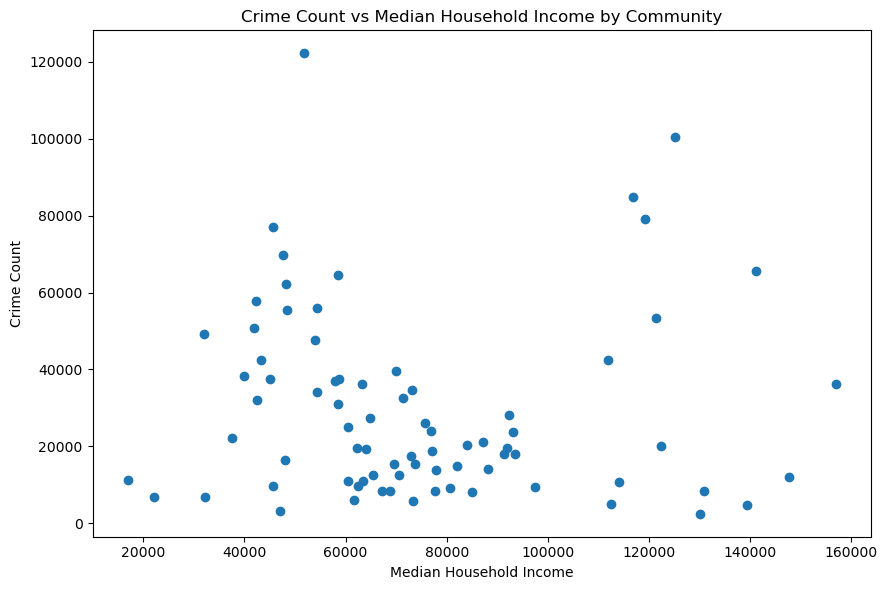

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.scatter(analysis_plot['INC_2020-2024'], analysis_plot['crime_count'])
plt.xlabel('Median Household Income')
plt.ylabel('Crime Count')
plt.title('Crime Count vs Median Household Income by Community')
plt.tight_layout()
plt.show()

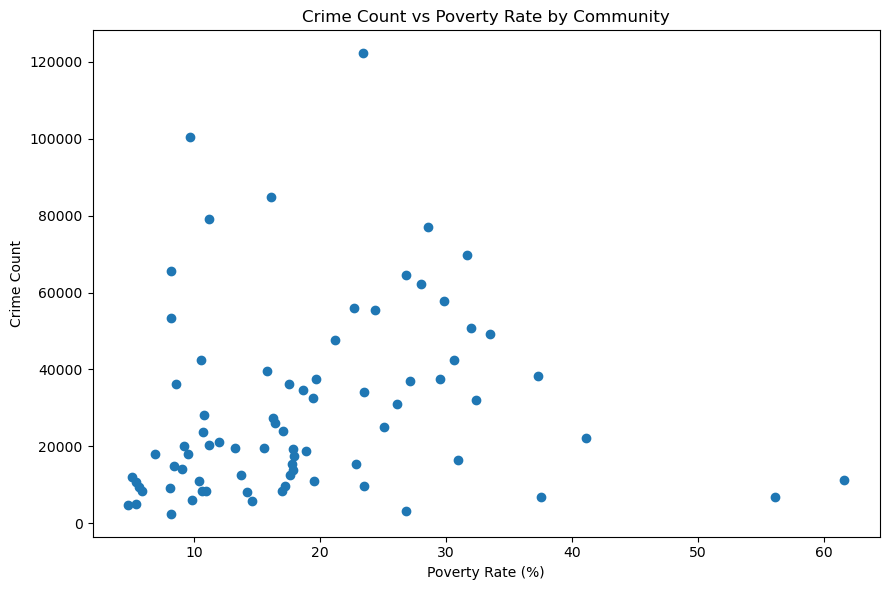

In [9]:
plt.figure(figsize=(9,6))
plt.scatter(analysis_plot['POV_2020-2024'], analysis_plot['crime_count'])
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Crime Count')
plt.title('Crime Count vs Poverty Rate by Community')
plt.tight_layout()
plt.show()

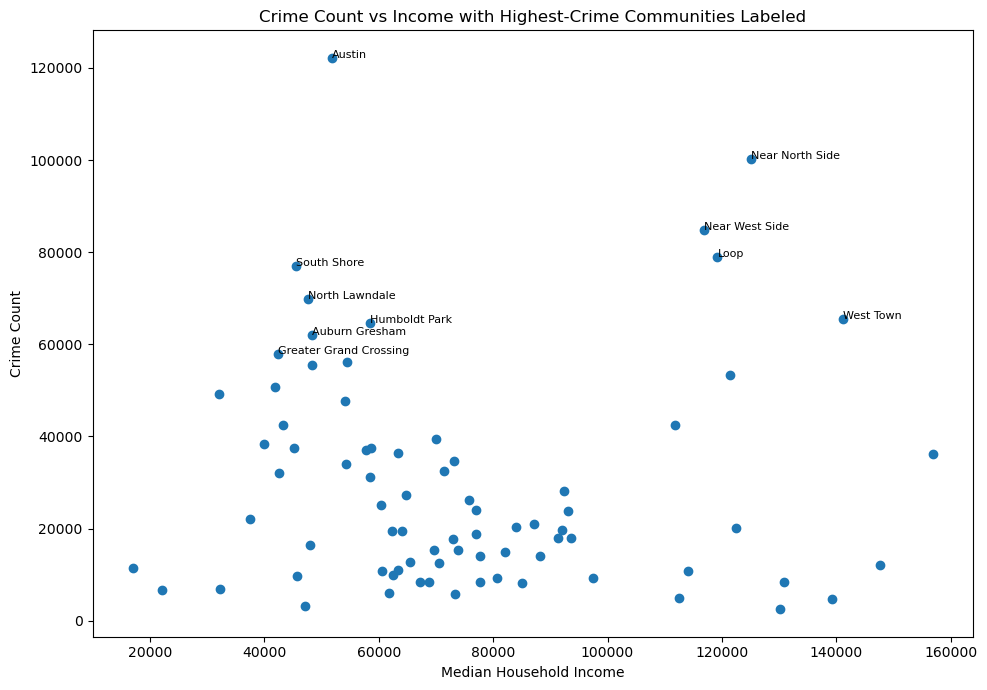

In [10]:
plt.figure(figsize=(10,7))
plt.scatter(analysis_plot['INC_2020-2024'], analysis_plot['crime_count'])

top_labels = analysis_plot.nlargest(10, 'crime_count')

for _, row in top_labels.iterrows():
    plt.text(
        row['INC_2020-2024'],
        row['crime_count'],
        row['community_name'],
        fontsize=8
    )

plt.xlabel('Median Household Income')
plt.ylabel('Crime Count')
plt.title('Crime Count vs Income with Highest-Crime Communities Labeled')
plt.tight_layout()
plt.show()

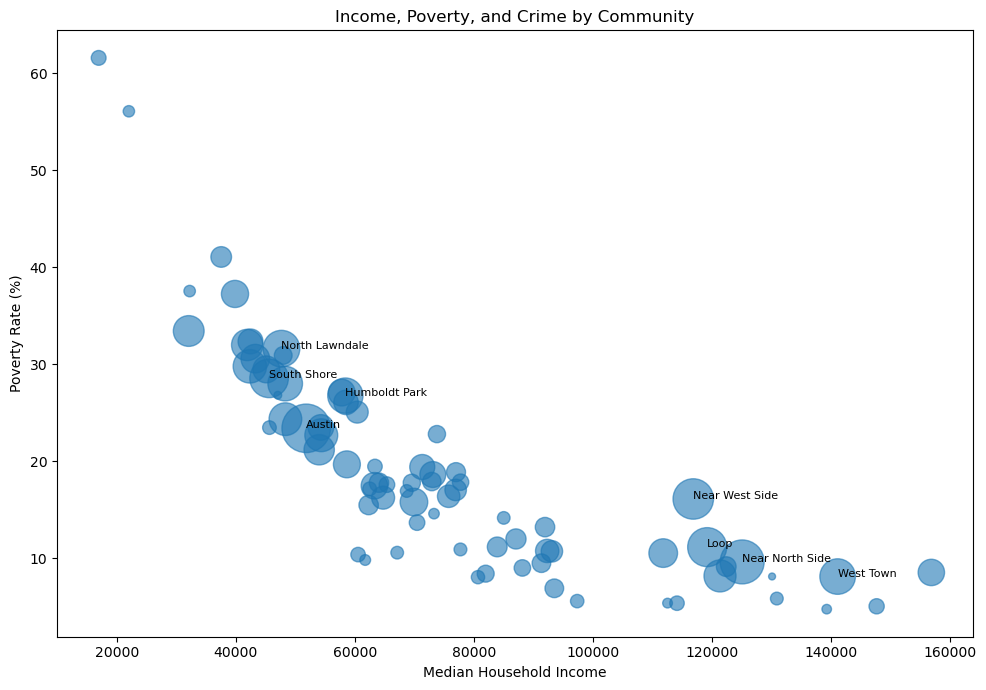

In [11]:
plt.figure(figsize=(10,7))
plt.scatter(
    analysis_plot['INC_2020-2024'],
    analysis_plot['POV_2020-2024'],
    s=analysis_plot['crime_count'] / 100,
    alpha=0.6
)


top_bubbles = analysis_plot.nlargest(8, 'crime_count')
for _, row in top_bubbles.iterrows():
    plt.text(
        row['INC_2020-2024'],
        row['POV_2020-2024'],
        row['community_name'],
        fontsize=8
    )

plt.xlabel('Median Household Income')
plt.ylabel('Poverty Rate (%)')
plt.title('Income, Poverty, and Crime by Community')
plt.tight_layout()
plt.show()

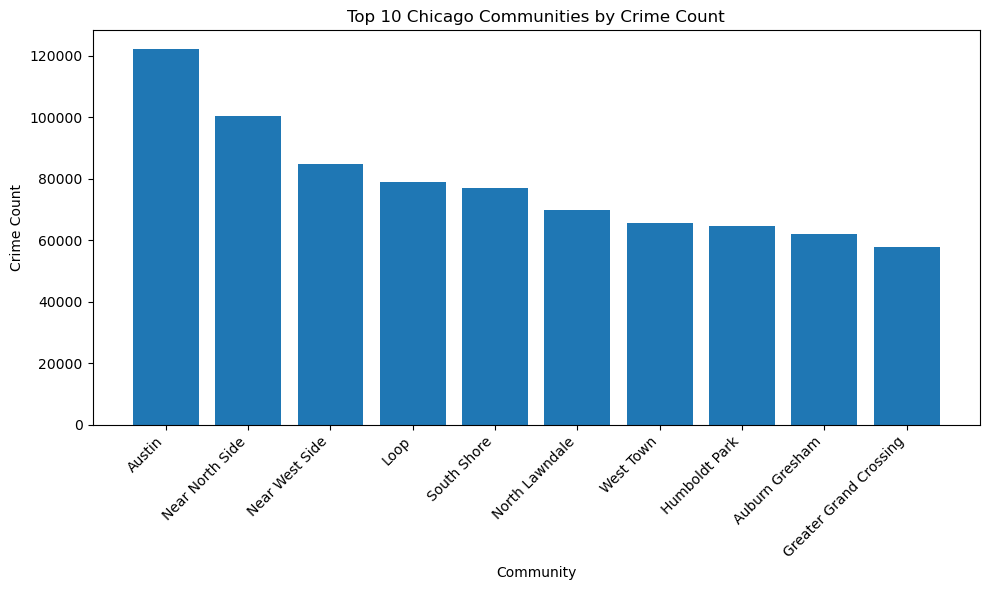

In [12]:
top10 = analysis_plot.sort_values('crime_count', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['community_name'], top10['crime_count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Community')
plt.ylabel('Crime Count')
plt.title('Top 10 Chicago Communities by Crime Count')
plt.tight_layout()
plt.show()

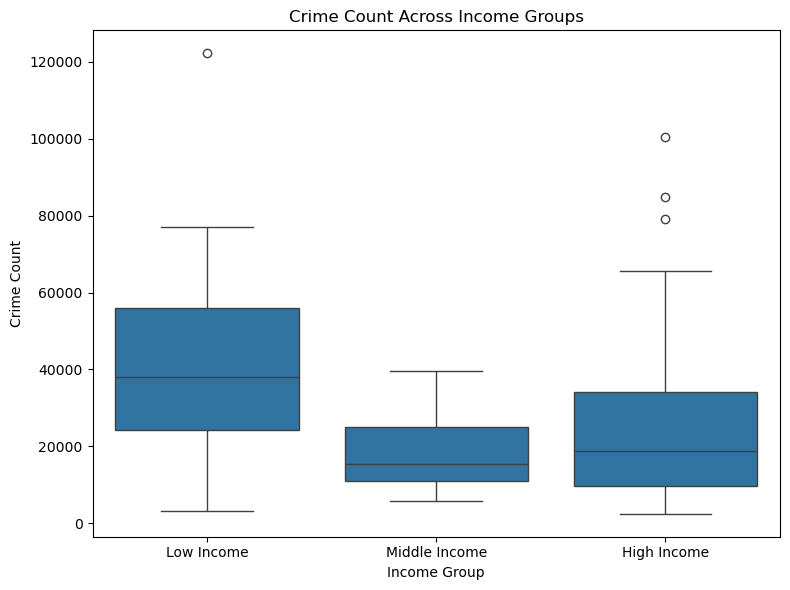

In [13]:
import seaborn as sns
analysis_plot['income_group'] = pd.qcut(
    analysis_plot['INC_2020-2024'],
    q=3,
    labels=['Low Income', 'Middle Income', 'High Income']
)

plt.figure(figsize=(8,6))
sns.boxplot(data=analysis_plot, x='income_group', y='crime_count')
plt.xlabel('Income Group')
plt.ylabel('Crime Count')
plt.title('Crime Count Across Income Groups')
plt.tight_layout()
plt.show()

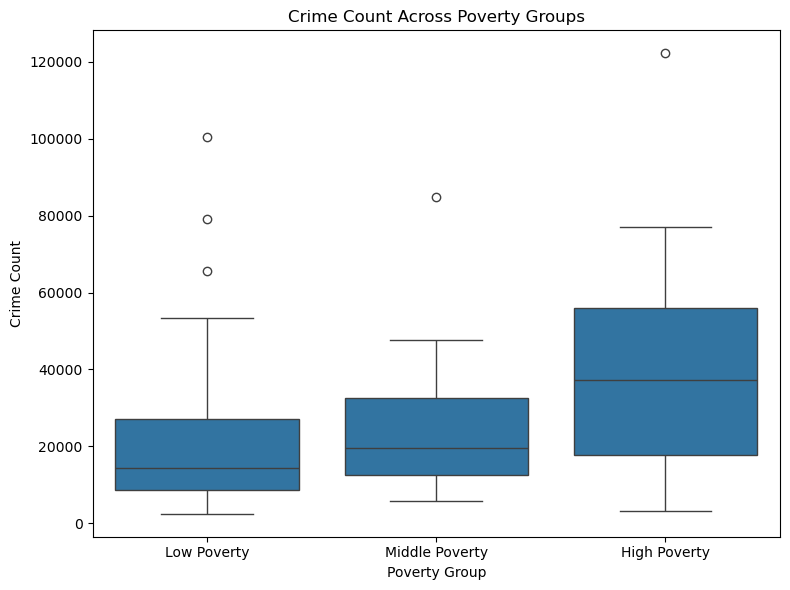

In [14]:
analysis_plot['poverty_group'] = pd.qcut(
    analysis_plot['POV_2020-2024'],
    q=3,
    labels=['Low Poverty', 'Middle Poverty', 'High Poverty']
)

plt.figure(figsize=(8,6))
sns.boxplot(data=analysis_plot, x='poverty_group', y='crime_count')
plt.xlabel('Poverty Group')
plt.ylabel('Crime Count')
plt.title('Crime Count Across Poverty Groups')
plt.tight_layout()
plt.show()

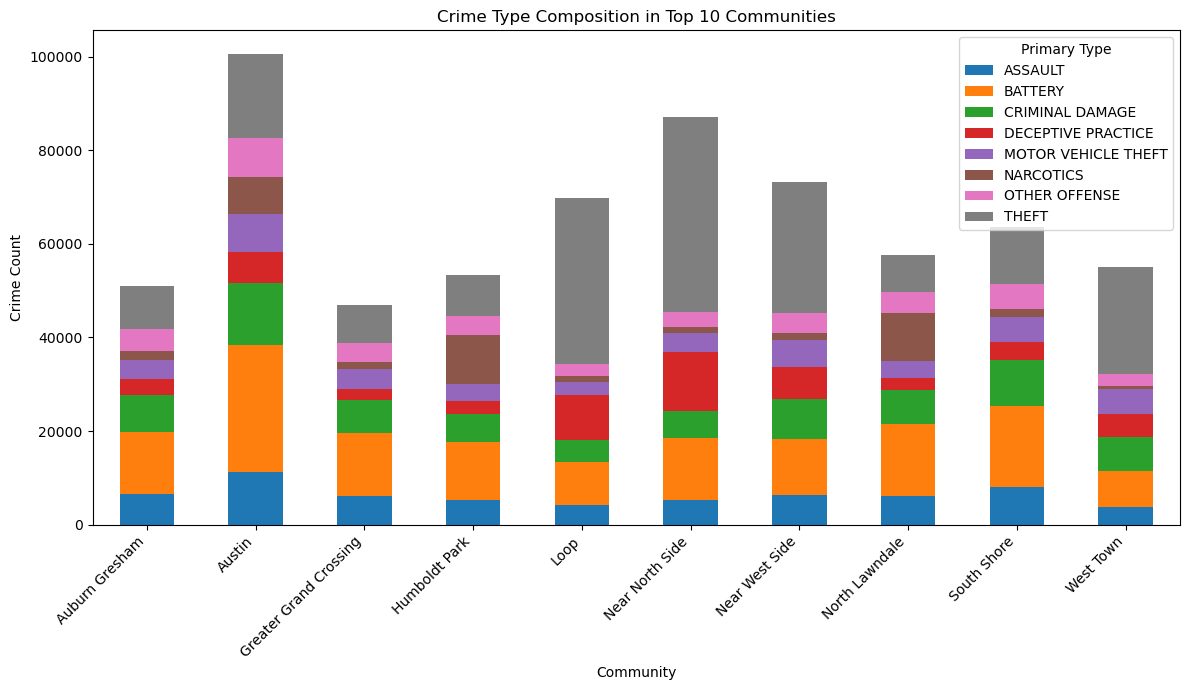

In [15]:
top10_names = top10['community_name'].tolist()

crime_type_top10 = (
    merged[merged['community_name'].isin(top10_names)]
    .groupby(['community_name', 'Primary Type'])
    .size()
    .reset_index(name='count')
)

top_types = (
    crime_type_top10.groupby('Primary Type')['count']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

crime_type_top10 = crime_type_top10[crime_type_top10['Primary Type'].isin(top_types)]

pivot_ct = crime_type_top10.pivot(
    index='community_name',
    columns='Primary Type',
    values='count'
).fillna(0)

pivot_ct.plot(kind='bar', stacked=True, figsize=(12,7))
plt.xlabel('Community')
plt.ylabel('Crime Count')
plt.title('Crime Type Composition in Top 10 Communities')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

               crime_count  INC_2020-2024  POV_2020-2024
crime_count       1.000000      -0.029956       0.155357
INC_2020-2024    -0.029956       1.000000      -0.806092
POV_2020-2024     0.155357      -0.806092       1.000000


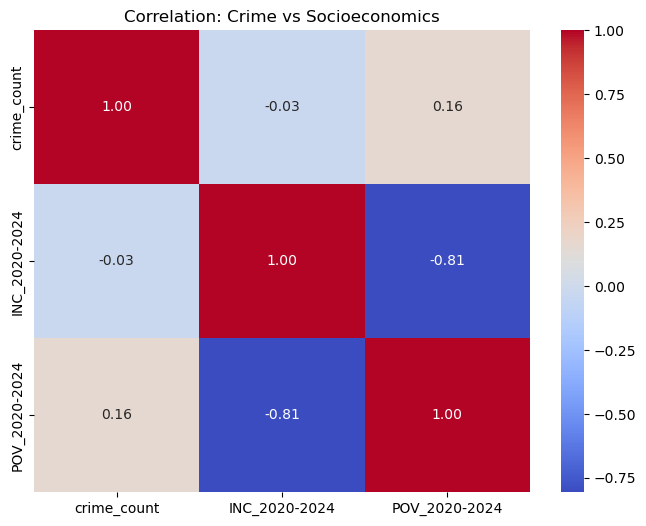

In [16]:
analysis['INC_2020-2024'] = pd.to_numeric(analysis['INC_2020-2024'])
analysis['POV_2020-2024'] = pd.to_numeric(analysis['POV_2020-2024'])

corr_matrix = analysis[['crime_count', 'INC_2020-2024', 'POV_2020-2024']].corr()
print(corr_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Crime vs Socioeconomics')
plt.show()

In [17]:
analysis['INC_2020-2024'] = pd.to_numeric(analysis['INC_2020-2024'], errors='coerce')
analysis['crime_count'] = pd.to_numeric(analysis['crime_count'], errors='coerce')

crime_mean = analysis['crime_count'].mean()
crime_std = analysis['crime_count'].std()

analysis['crime_zscore'] = (analysis['crime_count'] - crime_mean) / crime_std

outliers = analysis[analysis['crime_zscore'] > 2]
print("Statistical Outliers (Highest Crime Areas):")
print(outliers[['community_name', 'crime_count', 'INC_2020-2024']])

Statistical Outliers (Highest Crime Areas):
     community_name  crime_count  INC_2020-2024
7   Near North Side       100342  125101.326886
24           Austin       122185   51826.851402
27   Near West Side        84820  116881.232407
31             Loop        78993  119221.584097


In [18]:
from scipy import stats
clean_df = analysis.dropna(subset=['INC_2020-2024', 'crime_count'])

slope, intercept, r_value, p_value, std_err = stats.linregress(clean_df['INC_2020-2024'], clean_df['crime_count'])

print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")

R-squared: 0.0009
P-value: 0.7959


In [19]:
analysis.to_csv('crime_with_ses.csv', index=False)

In [20]:
print(analysis.columns)

Index(['community_id', 'crime_count', 'community_name', 'INC_2020-2024',
       'POV_2020-2024', 'crime_zscore'],
      dtype='object')
